In [1]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

/Users/u1166368/PawserVirtualisationTests/.pixi/envs/default/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 65219 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:65219/status,
Dashboard: http://127.0.0.1:65219/status,Workers: 11
Total threads: 11,Total memory: 18.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:65220,Workers: 0
Dashboard: http://127.0.0.1:65219/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:65245,Total threads: 1
Dashboard: http://127.0.0.1:65246/status,Memory: 1.64 GiB
Nanny: tcp://127.0.0.1:65223,


In [ ]:
"""
This cell just opens a netcdf which is sitting in my users object storage on Pawsey.
Mostly intended as a demo that the dataset actually exists, and has the right settings
to be openeed by an anonymous user.
"""

import xarray as xr

url = "s3://01deg/output980/iceh.2146-01.nc"

ds = xr.open_dataset(
    url,
    engine="h5netcdf",
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
)

# This is just straight up opening the dataset on Pawsy
# ds['sst_m'].isel(time=0).plot()
varnames = set(k for k in ds.variables.keys())
drop_vars = varnames - {"sst_m","time","nj","ni","ULON","ULAT"}

drop_vars = list(drop_vars)
print(ds)

In [ ]:
import warnings
import os
import xarray as xr
from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from obstore.store import S3Store
from obspec_utils.registry import ObjectStoreRegistry

import numcodecs.zarr3  # Register the zarr3 codec

from dotenv import load_dotenv

load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")
endpoint = "https://projects.pawsey.org.au"
bucket = "s3://01deg"


# # create anon s3 store
# store = S3Store.from_url(f"{scheme}{path}", endpoint=endpoint, skip_signature=True)

# create s3 store with aws-style credentials
store = S3Store.from_url(
    f"{bucket}",
    endpoint=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
)

registry = ObjectStoreRegistry({f"{bucket}": store})

warnings.filterwarnings(
    "ignore",
    message="Numcodecs codecs are not in the Zarr version 3 specification*",
    category=UserWarning,
)
parser = HDFParser()

In [ ]:
parser = HDFParser()

vds = open_virtual_dataset(
    url=f"{bucket}/output980/iceh.2146-01.nc",
    parser=parser,
    registry=registry,
)

In [ ]:
vds

We now have proof that we can open that netcdf with virtualizarr. Let's now try opening the entire contents of that bucket as a single virtual dataset.

Following that, we'll try to save it via icechunk

In [ ]:
import obstore

flist = []
for batch in obstore.list(store):
    for obj in batch:
        if not obj.get("path","icechunk").startswith("icechunk"):
            flist.append(obj.get("path"))

print(flist[:2])

In [ ]:
urls = [f"{bucket}/{f}" for f in flist[6:10]]

urls

In [ ]:
combined_vds = open_virtual_mfdataset(
    urls=urls,
    parser=parser,
    registry=registry,
    combine="nested",
    concat_dim="time",
    parallel="dask",
    compat="override",
    coords=["time"],
)
combined_vds

In [ ]:
import numpy as np

# ni and nj have no coordinate values in the source files.
# Assign them as plain numpy arrays so they survive virtualisation.
combined_vds = combined_vds.assign_coords(
    nj=("nj", np.arange(combined_vds.dims["nj"])),
    ni=("ni", np.arange(combined_vds.dims["ni"])),
)
combined_vds


In [ ]:
# Copied from `~/scratch/virtualizarr/test_nb.ipynb`
# Just using to save the combined virtual dataset as a zarr via icechunk, so we
# don't have to fetch it from pawsey to rebuild it there if something crashes
import xarray as xr
import icechunk
from pathlib import Path

if Path("/Users/u1166368/scratch/virtualizarr/pawsey/01deg").exists():
    import shutil
    shutil.rmtree("/Users/u1166368/scratch/virtualizarr/pawsey/01deg")

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

# credentials = icechunk.containers_credentials(
#     { "s3://my_s3_bucket": icechunk.s3_credentials(bucket="my-s3-bucket", region="us-east-1"),
#       "s3://my_other_s3_bucket": icechunk.s3_credentials(bucket="my-other-s3-bucket", region="us-west-2"),
#     }
# )

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/scratch/virtualizarr/pawsey/01deg")
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey 01deg virtual dataset to local zarr store for testing")

In [ ]:
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.local_filesystem_storage("/Users/u1166368/scratch/virtualizarr/pawsey/01deg")
repo = icechunk.Repository.open(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
session = repo.readonly_session("main")
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).plot()

In [ ]:
import matplotlib.pyplot as plt
_arr = xr.open_zarr(session.store, consolidated=False)['sst_m'].data.blocks[0,0,0].compute().squeeze()
plt.pcolor(_arr)

### Works locally - so write to pawsey

In [ ]:
# Now put the virtual dataset in the bucket alongside the netcdf files
import xarray as xr
import icechunk
from pathlib import Path

# Create a new repository instance with virtual chunk container permissions for reading
config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=f"{bucket}/",
        store=icechunk.s3_store(
            endpoint_url=endpoint,              # "https://projects.pawsey.org.au"
            s3_compatible=True,
            force_path_style=True,
        )
    ),
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

# Open the repository with the config that includes virtual chunk permissions
storage = icechunk.s3_storage(
    bucket='01deg',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)
repo = icechunk.Repository.create(storage, config, authorize_virtual_chunk_access=credentials)

# Write your virtual dataset to the repository
write_session = repo.writable_session("main")
combined_vds.vz.to_icechunk(write_session.store)
write_session.commit("Write Pawsey 01deg virtual dataset to acacia zarr store for testing")

In [ ]:
combined_vds

In [ ]:
# And write to a local kerchunk container using json
combined_vds.vz.to_kerchunk(
    filepath="//Users/u1166368/scratch/virtualizarr/pawsey/ref-01deg.json",
    format='json',
)

In [ ]:
import fsspec

refs = combined_vds.vz.to_kerchunk(format='dict')

with fsspec.open(
    "s3://01deg/reference.json",
    "wb",
    client_kwargs={"endpoint_url": endpoint},
    key=access_key_id,
    secret=secret_access_key,
) as f:
    import json
    f.write(json.dumps(refs).encode("utf-8"))

In [ ]:
# And try as parquet too
combined_vds.vz.to_kerchunk(
    filepath="file:///Users/u1166368/scratch/virtualizarr/pawsey/ref-01deg.pq",
    format='parquet',
    record_size=50_000
)

In [ ]:
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

In [ ]:
import icechunk
from dotenv import load_dotenv
load_dotenv()

access_key_id = os.environ.get("ACCESS_KEY_ID")
secret_access_key = os.environ.get("SECRET_ACCESS_KEY")

endpoint = "https://projects.pawsey.org.au"
bucket = "s3://01deg"
path = "output980/iceh.2146-01.nc"

storage = icechunk.s3_storage(
    bucket='01deg',
    prefix='icechunk',
    endpoint_url=endpoint,
    access_key_id=access_key_id,
    secret_access_key=secret_access_key,
    force_path_style=True,
)

credentials = icechunk.containers_credentials(
    { 
        bucket: icechunk.s3_credentials(
            access_key_id=access_key_id, 
            secret_access_key=secret_access_key,
        )
    }
)

repo = icechunk.Repository.open(storage=storage, config=None, authorize_virtual_chunk_access=credentials)

session = repo.readonly_session("main")

In [ ]:
xr.open_zarr(session.store, consolidated=False)['sst_m']

In [ ]:
xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(0,1000), nj=slice(500,1250)).plot()

In [ ]:
import matplotlib.pyplot as plt
import xarray as xr

xr.open_zarr(session.store, consolidated=False)['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
import xarray as xr

url = "s3://01deg/reference.json"

ds = xr.open_dataset(
    url,
    backend_kwargs={
        "storage_options": {
            "anon": True,
            "client_kwargs": {"endpoint_url": "https://projects.pawsey.org.au"},
        }
    },
)
ds['sst_m'].isel(time=0, ni=slice(400,1350), nj=slice(0,1200)).plot()

In [ ]:
import xarray as xr
from dask.distributed import Client

client = Client(threads_per_worker=1)
client

url = "/Users/u1166368/scratch/virtualizarr/pawsey/ref-01deg.json"

# This is a bit of a mouthful...
ds = xr.open_dataset(
    "reference://", engine="zarr",
    backend_kwargs={
        "storage_options": {
            "fo": url,
            "remote_protocol": "s3",
            "remote_options": {
                "asynchronous": True, 
                "anon": True,
                "endpoint_url": "https://projects.pawsey.org.au",
                }
        },
        "consolidated": False
    }, 
)
ds

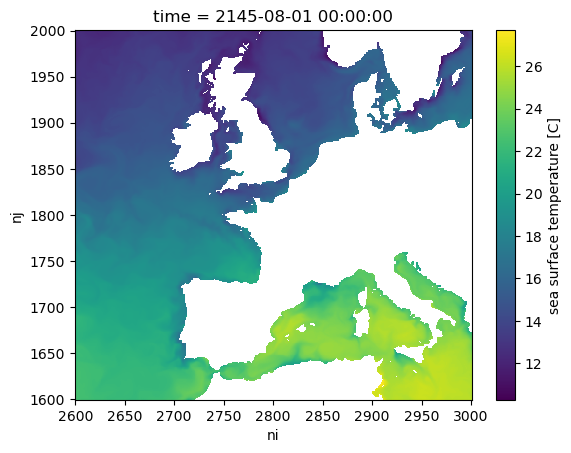

In [3]:
ds['sst_m'].isel(time=0).sel(ni=slice(2600,3000), nj=slice(1600,2000)).plot()

In [ ]:
# Takes about 0.5-1S to stream and plot this lovely map of THE WORLD ACCORDING TO 
# THE ENGLISH (I chose this because of it's relatively small area)

In [ ]:
client.close()